# CIC-IDS-2017 Network Intrusion Dataset - Network Baseline + Attacker Classification 
### Flow Level Intrusion Detection

This notebook uses CIC-IDS-2017 flow data for two purposes:

### Part A - Baseline Anomaly Modeling (Unsupervised)
We first establish a "normal traffic" baseline using BENIGN flows and train an unsupervised anomaly model. This helps validata preprocessing and feature engineering to provide anomaly socre distributions. 
- Isolation Forest


### Part B - Attack Type Classification (Supervised) - to be added
Next, we will train a supervised classifer using labeled CIC-IDS traffic to predict attack categories
- Predict attack labels on new flow data
- Provide class probabilities
- Serve as baseline for future real honepot traffic classifiers. 

CIC-IDS2017 intrusion dataset:  
https://www.kaggle.com/datasets/chethuhn/network-intrusion-dataset  
This dataset contains labeled network traffic including both normal activity and multiple cyberattacks (brute force, DoS, infiltration), making it a common benchmark for intrusion detection research and anomaly analysis.

Information to download the dataset are in `machine-learning/data/READ.me`

Note: CIC-IDS is flow level, so it does not include password attemps or command level features

In [1]:
#uncomment to check which python version/enviornment is running script 
#import sys
#print(sys.executable)

#imports
import os
import json
import gzip
import math
from pathlib import Path
from datetime import datetime
from typing import Any, Dict, Iterable, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import average_precision_score
from sklearn.metrics import roc_curve
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import PrecisionRecallDisplay
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.decomposition import PCA


### Shannon Entropy 
Shannon entropy measures password strength in bits, representing min number of guesses needed to guess it.

The Shannon entropy is defined as:
$$
H = -\sum_{i=1}^{n} p(x_i)\log_2 p(x_i)
$$

where:
- $p(x_i)$ is the probability of character $x_i$ in the password  
- $n$ is the number of unique characters  

This helps us measure how unpredictable a password string is.

- Higher entropy → more randomness → more human-like
- Medium entropy → common human style passwords
- Lower entropy → repetitive/simple → more bot-like

<u> Character distribution entropy:</u> Instead of estimating entropy from the allowed character pool, we compute it from the actual characters used. This better captures repetition patterns, structured guesses, and dictionary based attacks.

In our pipeline, entropy is computed per password attempt and can be aggregated per session (mean entropy or maximum entropy) to characterize attacker behavior.


In [2]:
def shannon_entropy(s:str) ->float:
    #handles missing values or nons trings
    if s is None or (isinstance(s, float) and np.isnan(s)):
        return 0.0
    
    s=str(s)
    if len(s) == 0:
        return 0.0
        
    #counts how many times each character appears
    #stored in dict - ex: "aab1"-> {'a':2, 'b':1, '1':1}
    counts= {}
    for ch in s:
        counts[ch]= counts.get(ch, 0)+1
    
    #compute probability by dividing count by total length of string
    #ex: [2,1,1]/4 -> [0.5, 0.25, 0.25]
    probs= np.array(list(counts.values()), dtype=float)/ len(s)
    #apply shannon entropy formula 
    #measures how unpredictable the character distribution is
    entropy= -(probs*np.log2(probs)).sum()

    #low values -> low entropy 
    #high values -> high entropy 
    return float(entropy)

### Preprocessing
- Load in CSV files from data and combine into one large data frame

In [3]:
#path for network intrustion data
NETWORK_DIR = Path("../data/Kaggle CIC-IDS-2017")
csv_files = sorted(NETWORK_DIR.glob("*.pcap_ISCX.csv"))

#prints found CSV files
print("CSV files:", len(csv_files))
for f in csv_files[:8]:
    print(" -", f.name)

#combines all dataset into one large data frame
dfs= []
for f in csv_files:
    df= pd.read_csv(f)
    dfs.append(df)

net_df= pd.concat(dfs, ignore_index=True)
print("Network shape:", net_df.shape)
print("Columns:", len(net_df.columns))
#Network shape: (2830743, 79)
#Columns: 79
#show some rows of the dataset 
#net_df.head()
net_df.sample(10)

CSV files: 8
 - Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
 - Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
 - Friday-WorkingHours-Morning.pcap_ISCX.csv
 - Monday-WorkingHours.pcap_ISCX.csv
 - Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
 - Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
 - Tuesday-WorkingHours.pcap_ISCX.csv
 - Wednesday-workingHours.pcap_ISCX.csv
Network shape: (2830743, 79)
Columns: 79


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
2153822,53,30864,1,1,44,184,44,44,44.0,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1594972,80,5922799,3,1,0,0,0,0,0.0,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,Web Attack � XSS
451595,443,14,1,1,6,6,6,6,6.0,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
868950,53,64987884,2,2,94,295,48,46,47.0,1.414214,...,20,59988.0,0.0,59988,59988,64856963.0,0.0,64856963,64856963,BENIGN
1685409,389,118,2,2,328,326,164,164,164.0,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1295505,53,171,2,2,70,102,35,35,35.0,0.000000,...,40,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
324896,555,44,1,1,2,6,2,2,2.0,0.000000,...,24,0.0,0.0,0,0,0.0,0.0,0,0,PortScan
779622,443,190503,15,12,1446,10051,965,0,96.4,250.892350,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2046463,53,237,2,2,58,570,29,29,29.0,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
901377,53,419,1,1,52,113,52,52,52.0,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


### Feature Engineering 
Convet raw network flow data into behavioral features and plot distributions

These approximate session behavior using:
- Flow duration
- Packet counts
- Packet rates
- Byte throughput
- TCP flags
- Inter-arrival timing

In [4]:
#clean col names and check for required cols for features
net_df.columns= [c.strip() for c in net_df.columns]
required_cols = [
    "Flow Duration",
    "Total Fwd Packets",
    "Total Backward Packets",
    "Flow Bytes/s",
    "Flow Packets/s",
    "Flow IAT Mean",
    "Flow IAT Std",
    "SYN Flag Count",
    "RST Flag Count",
    "FIN Flag Count",
    "Packet Length Mean",
    "Packet Length Std",
    "Down/Up Ratio",
    "Label"
]
missing= [c for c in required_cols if c not in net_df.columns]
if missing:
    raise ValueError(f"Missing req cols: {missing}")

#convert time to secs 
dur_us= pd.to_numeric(net_df["Flow Duration"], errors="coerce")
session_duration_s= dur_us / 1e6 

#packet count
fwd_pkts= pd.to_numeric(net_df["Total Fwd Packets"], errors="coerce").fillna(0.0)
bwd_pkts= pd.to_numeric(net_df["Total Backward Packets"], errors="coerce").fillna(0.0)
packet_count= (fwd_pkts+bwd_pkts)

net_features = pd.DataFrame({
    "session_duration_s": session_duration_s,
    "packet_count": packet_count,
})

#packets per min 
#ignore flows shorter than 10 ms for rate computation
MIN_DUR_S= 0.01  
valid= net_features["session_duration_s"]>= MIN_DUR_S

net_features["packets_per_min"]= 0.0
net_features.loc[valid, "packets_per_min"]=(
    net_features.loc[valid, "packet_count"]/(net_features.loc[valid, "session_duration_s"]/60.0)
)

extra_numeric_cols= [
    "Flow Bytes/s",
    "Flow Packets/s",
    "Flow IAT Mean",
    "Flow IAT Std",
    "SYN Flag Count",
    "RST Flag Count",
    "FIN Flag Count",
    "Packet Length Mean",
    "Packet Length Std",
    "Down/Up Ratio",
]

for col in extra_numeric_cols:
    net_features[col] = pd.to_numeric(net_df[col], errors="coerce").fillna(0.0)

#no pass data in this data
net_features["avg_password_entropy"]= 0.0

#get labels
net_labels = net_df["Label"].astype(str)

#cleanup and fill any missing values with 0
net_features.replace([np.inf, -np.inf], np.nan, inplace=True)
net_features.fillna(0.0, inplace=True)

print("Feature data frame shape:", net_features.shape)
net_features.describe()

Feature data frame shape: (2830743, 14)


,session_duration_s,packet_count,packets_per_min,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,SYN Flag Count,RST Flag Count,FIN Flag Count,Packet Length Mean,Packet Length Std,Down/Up Ratio,avg_password_entropy
count,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2830743.0
mean,1.478566e+01,1.975493e+01,1.685272e+03,1.490208e+06,7.078247e+04,1.298449e+06,2.919271e+06,4.644646e-02,2.423392e-04,3.537976e-02,1.719444e+02,2.949756e+02,6.835004e-01,0.0
std,3.365374e+01,1.746663e+03,5.021521e+03,2.592706e+07,2.542966e+05,4.507944e+06,8.045870e+06,2.104500e-01,1.556536e-02,1.847378e-01,3.054915e+02,6.318001e+02,6.804920e-01,0.0
min,-1.300000e-05,2.000000e+00,0.000000e+00,-2.610000e+08,-2.000000e+06,-1.300000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0
25%,1.550000e-04,2.000000e+00,0.000000e+00,1.191355e+02,3.341404e+00,6.366667e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,6.000000e+00,0.000000e+00,0.000000e+00,0.0
50%,3.131600e-02,4.000000e+00,1.251872e+01,4.569281e+03,1.082163e+02,1.143884e+04,1.371787e+02,0.000000e+00,0.000000e+00,0.000000e+00,5.720000e+01,2.598076e+01,1.000000e+00,0.0
75%,3.204829e+00,8.000000e+00,1.670359e+03,1.649485e+05,2.325581e+04,3.374266e+05,6.912663e+05,0.000000e+00,0.000000e+00,0.000000e+00,1.198000e+02,1.743239e+02,1.000000e+00,0.0
max,1.200000e+02,5.116810e+05,5.250764e+05,2.071000e+09,4.000000e+06,1.200000e+08,8.480026e+07,1.000000e+00,1.000000e+00,1.000000e+00,3.337143e+03,4.731522e+03,1.560000e+02,0.0


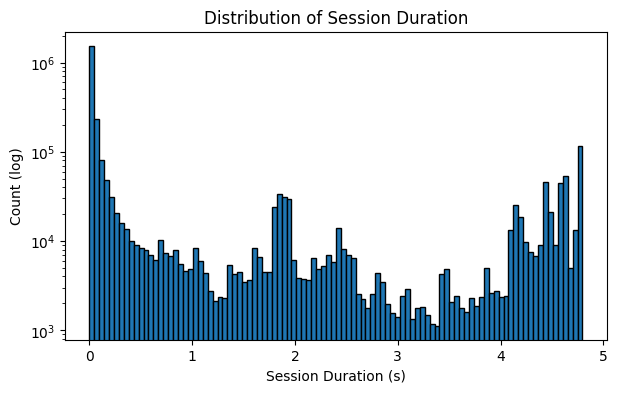

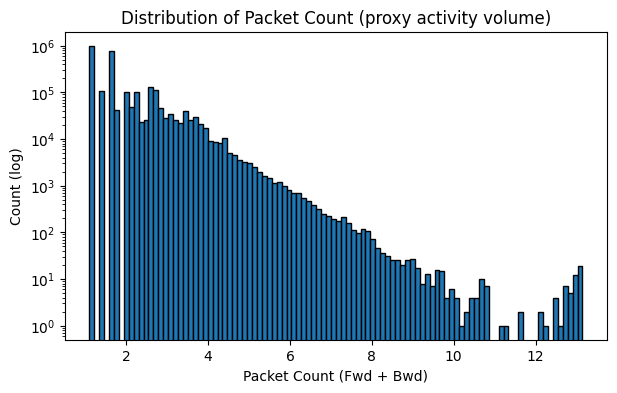

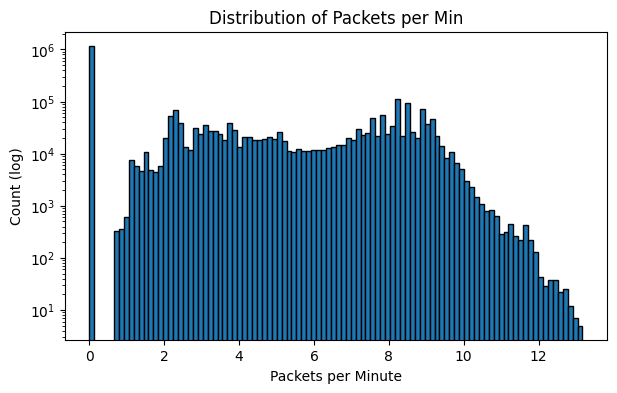

In [5]:
#log transform heavy tailed features
log_cols=[
    "session_duration_s",
    "packet_count",
    "packets_per_min",
    "Flow Bytes/s",
    "Flow Packets/s",
]

for col in log_cols:
    if col in net_features.columns:
        net_features[col] = np.log1p(np.clip(net_features[col], 0, None))
        
#plot distributions
#session duration 
plt.figure(figsize=(7,4))
plt.hist(net_features["session_duration_s"], bins=100, edgecolor="black", log=True)
plt.xlabel("Session Duration (s)")
plt.ylabel("Count (log)")
plt.title("Distribution of Session Duration")
plt.show()

#packet counts
plt.figure(figsize=(7,4))
plt.hist(net_features["packet_count"], bins=100, edgecolor="black", log=True)
plt.xlabel("Packet Count (Fwd + Bwd)")
plt.ylabel("Count (log)")
plt.title("Distribution of Packet Count (proxy activity volume)")
plt.show()

#packets per min
plt.figure(figsize=(7,4))
plt.hist(net_features["packets_per_min"], bins=100, edgecolor="black", log=True)
plt.xlabel("Packets per Minute")
plt.ylabel("Count (log)")
plt.title("Distribution of Packets per Min")
plt.show()

### Baseline Anomaly Model using Isolation Forest
Train an Isolation Forest modle using only BENIGN flows.
- Learn what normal traffic looks like
- Assign anomaly scores to all flows
- How attack traffic separates from baseline


Total flows: 2830743
BENIGN flows: 2273097
Non BENIGN flows: 557646
Finished training baseline anomaly model on BENIGN flows only
Mean score BENIGN: 0.4266184957719508
Mean score non-BENIGN: 0.5154755072275718


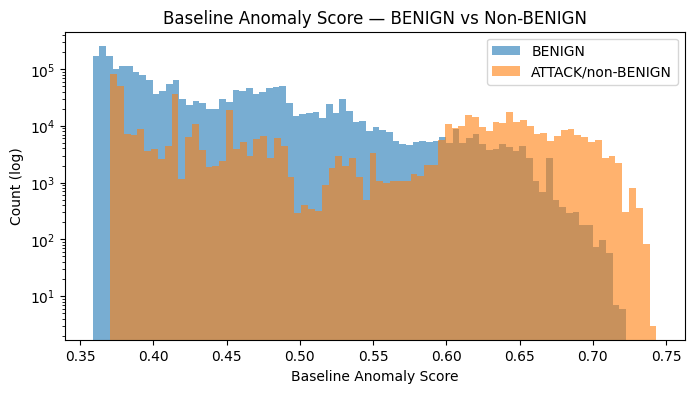

Evalutation Metrics:
ROC-AUC (BENIGN vs non-BENIGN) using baseline scores: 0.7113851484704602


In [6]:
feature_cols = list(net_features.columns)

#define BENIGN mask
benign_mask= net_labels.str.upper().eq("BENIGN")
print("Total flows:", len(net_features))
print("BENIGN flows:", int(benign_mask.sum()))
print("Non BENIGN flows:", int((~benign_mask).sum()))

#use BENIGN only for training data
X_benign = net_features.loc[benign_mask, feature_cols].copy()
#drop extreme outliers in BENIGN to make baseline tighter 
X_benign = X_benign.clip(lower=X_benign.quantile(0.001), upper=X_benign.quantile(0.999), axis=1)

baseline_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("iso", IsolationForest(
        n_estimators=400,
        contamination=0.03,  
        random_state=42
    ))
])

#trainin on BENIGN to learn normal session durations, packet counts, and packet rates 
baseline_pipe.fit(X_benign)
print("Finished training baseline anomaly model on BENIGN flows only")

#score all flows using the BENIGN trained model
#compare how abnormal eeach session is with the baseline using anomaly scores
X_all= net_features[feature_cols].copy()

scores_all= -baseline_pipe.named_steps["iso"].score_samples(
    baseline_pipe.named_steps["scaler"].transform(X_all)
)

#high score= more abnormal
scored_net= net_features.copy()
scored_net["Label"] = net_labels
scored_net["baseline_anomaly_score"] = scores_all
scored_net["is_benign"] = benign_mask.astype(int)

print("Mean score BENIGN:", float(scored_net.loc[scored_net["is_benign"]==1, "baseline_anomaly_score"].mean()))
print("Mean score non-BENIGN:", float(scored_net.loc[scored_net["is_benign"]==0, "baseline_anomaly_score"].mean()))

#plot distributions
plt.figure(figsize=(8,4))
plt.hist(scored_net.loc[scored_net["is_benign"]==1, "baseline_anomaly_score"], bins=80, alpha=0.6, label="BENIGN", log=True)
plt.hist(scored_net.loc[scored_net["is_benign"]==0, "baseline_anomaly_score"], bins=80, alpha=0.6, label="ATTACK/non-BENIGN", log=True)
plt.xlabel("Baseline Anomaly Score")
plt.ylabel("Count (log)")
plt.title("Baseline Anomaly Score — BENIGN vs Non-BENIGN")
plt.legend()
plt.show()

print("Evalutation Metrics:")
#roc-auc score
#tells us how well the baseline scores separate non-benign samples from benign ones 
#if I randomly pick one non-benign sample and one benign sample, what is the probability that the model gives the non-benign one a higher score?
y = (~benign_mask).astype(int)  #1= non benign
auc = roc_auc_score(y, scores_all)
print("ROC-AUC (BENIGN vs non-BENIGN) using baseline scores:", auc)



### Supervised Attack Classification (Next Section)